<table style="width: 100%; border-collapse: collapse; border: none; background: #fffbeb; border-left: 6px solid #f59e0b; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #78350f; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        A*: el GPS que Nunca se Equivoca 🧸⭐
      </h1>
      <p style="margin: 6px 0 0 0; color: #b45309; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Edición Didáctica: Para Dummies (No Expertos)
      </p>
      <p style="margin: 4px 0 0 0; color: #92400e; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #f59e0b; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Algoritmos de Búsqueda (Dummies)
      </span><br>
      <span style="color: #92400e; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #b45309; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
## ¿Qué vamos a aprender aquí? 🎈

Piensa en el GPS de tu celular. Cuando calcula una ruta, no sólo mira "qué tan cerca en línea recta" está el destino (eso sería como nuestro detective con olfato del cuaderno 02): **también** toma en cuenta cuánto camino ya recorriste y qué tan largas son las calles reales.

Eso es exactamente **A\* (A-estrella)**: combina dos cosas...

* 🚗 **Lo que ya recorriste** (`g`): cuántas carpetas ya abriste para llegar hasta aquí.
* 🧭 **Lo que crees que falta** (`h`): tu estimación de cuánto falta para llegar (el "olfato" del cuaderno 02).

Sumando ambas cosas (`f = g + h`), A* toma SIEMPRE la mejor decisión posible, sin dejarse engañar por pistas falsas ni ignorar el esfuerzo ya invertido.

---
## 1. Un Atajo en la Oficina 🚪

Para que la ventaja de A* se note de verdad, vamos a imaginar que la oficina tiene un **atajo**: una puerta especial en la entrada (`AccesoDirecto`) que lleva DIRECTO a la carpeta `Informes` del Proyecto Norte, sin tener que pasar por todos los armarios intermedios.

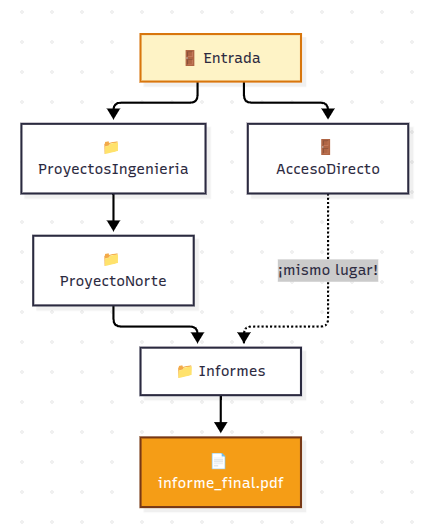

* Ruta larga: `Entrada → ProyectosIngenieria → ProyectoNorte → Informes → informe_final.pdf` (4 puertas)
* Ruta corta (atajo): `Entrada → AccesoDirecto → Informes → informe_final.pdf` (3 puertas)

In [ ]:
# La carpeta "Informes" es la MISMA en ambos casos (no una copia):
# así, sin importar por cuál puerta lleguemos, sabemos exactamente cuánto falta.
informes_proyecto_norte = {"informe_avance.pdf": None, "informe_final.pdf": None}

oficina = {
    "ProyectosIngenieria": {
        "ProyectoNorte": {"planos.dwg": None, "Informes": informes_proyecto_norte},
        "ProyectoSur": {"Informes": {"informe_preliminar.pdf": None}},
    },
    "AccesoDirecto": {"Informes": informes_proyecto_norte},   # <- lleva a la MISMA carpeta, no una copia
}

objetivo = "informe_final.pdf"
print("La oficina ahora tiene un atajo. Armarios principales:", list(oficina.keys()))

---
## 2. Dándole a A* una Estimación Justa (`h`) 🧮

Para que A* funcione bien, necesitamos que su estimación (`h`) del camino restante sea **honesta**: nunca debe decir que falta MÁS de lo que en realidad falta. Aquí, como ya construimos el mapa, le damos una tabla de estimaciones ya calculada (como si un compañero que conoce bien la oficina nos hubiera avisado cuántas puertas exactas faltan desde cada lugar):

In [ ]:
estimacion_puertas_restantes = {
    "ProyectosIngenieria": 3,
    "ProyectoNorte": 2,
    "AccesoDirecto": 2,
    "Informes": 1,
    "informe_final.pdf": 0,
}

# Para cualquier lugar que no esté en la tabla, usamos un valor "conservador"
# (nunca decimos que falta MÁS de lo que realmente sabemos que puede faltar).
VALOR_CONSERVADOR = 4

def estimar_faltante(nombre):
    return estimacion_puertas_restantes.get(nombre, VALOR_CONSERVADOR)

for lugar in ["ProyectosIngenieria", "AccesoDirecto", "Informes", "informe_final.pdf"]:
    print(f"Desde '{lugar}', A* estima que faltan {estimar_faltante(lugar)} puerta(s).")

---
## 3. Programando A*: `f = g + h` 🧑‍🔬

Cada vez que A* evalúa un lugar, suma **lo ya recorrido** (`g`, el número de puertas que ya abrió) más **lo que estima que falta** (`h`). Siempre elige abrir la puerta con la suma (`f`) más baja.

In [ ]:
import heapq

def buscar_astar(mapa, nombre_objetivo):
    contador = 0
    libreta = []
    for nombre, contenido in mapa.items():
        g = 1  # ya abrimos 1 puerta para llegar aquí desde la entrada
        h = estimar_faltante(nombre)
        heapq.heappush(libreta, (g + h, contador, g, [nombre], nombre, contenido))
        contador += 1

    orden_visitado = []
    while libreta:
        f, _, g, camino, nombre_actual, contenido_actual = heapq.heappop(libreta)
        orden_visitado.append(nombre_actual)

        if nombre_actual == nombre_objetivo:
            return camino, orden_visitado, g

        if contenido_actual is not None:
            for nombre_hijo, contenido_hijo in contenido_actual.items():
                g_hijo = g + 1
                h_hijo = estimar_faltante(nombre_hijo)
                contador += 1
                heapq.heappush(libreta, (g_hijo + h_hijo, contador, g_hijo,
                                          camino + [nombre_hijo], nombre_hijo, contenido_hijo))

    return None, orden_visitado, None


camino_astar, orden_astar, puertas_astar = buscar_astar(oficina, objetivo)

print("⭐ Resultado de A*:")
print("   Camino encontrado:", " → ".join(camino_astar))
print(f"   Puertas abiertas en el camino: {puertas_astar}")
print(f"   Carpetas/archivos revisados: {len(orden_astar)}")

### 🤔 ¿Qué acaba de pasar?

A* encontró el camino **corto** (`AccesoDirecto → Informes → informe_final.pdf`, 3 puertas contando la de entrada al primer armario), ¡y revisando muy pocos lugares en el camino! A diferencia de nuestro detective con olfato del cuaderno 02 (GBFS), A* sí "recuerda" cuánto ha caminado, así que nunca se deja engañar por un atajo que en realidad es más largo, ni ignora un atajo real que sí le conviene.

---
## 4. La Gran Carrera Final: los Cuatro Buscadores 🏁

| Buscador | ¿Usa pistas del nombre? | ¿Recuerda el camino ya hecho? | ¿Garantiza el camino más corto? |
|---|---|---|---|
| **DFS** 🕳️ | No | No | No |
| **BFS** 🌊 | No | Sí (indirectamente, por niveles) | Sí, si todas las puertas "cuestan" lo mismo |
| **GBFS** 🕵️ | Sí | No | No |
| **A\*** ⭐ | Sí | Sí | **Sí**, si la estimación es honesta |

A* es como el GPS perfecto: usa pistas (como GBFS) PERO nunca olvida cuánto camino ya llevas (como BFS). Por eso combina lo mejor de los dos mundos.

---
## 🎯 Resumen Relámpago ⚡

| Idea Clave | Explicación en 5 segundos |
|---|---|
| **A\*** | Suma lo ya recorrido (`g`) más lo que estima que falta (`h`), y siempre elige el camino con la suma más baja. |
| **Estimación honesta** | `h` nunca debe decir que falta MÁS de lo que realmente falta; si se cumple, A* siempre encuentra el camino más corto. |
| **A* vs. GBFS** | GBFS sólo mira el olfato (`h`) y puede engañarse; A* también recuerda el esfuerzo ya invertido (`g`), así que no se deja engañar. |
| **A* vs. BFS** | BFS también encuentra el camino más corto, pero revisando casi todo; A* llega ahí revisando muchísimo menos, gracias a sus pistas. |

¡Felicidades! 🎉 Con este cuaderno completaste el recorrido por los cuatro algoritmos de búsqueda clásicos de la Inteligencia Artificial: DFS, BFS, GBFS y A*. Ahora estás listo para resistir el taller práctico evaluativo del módulo.

### 🧠 Para pensar (sin necesidad de responder por escrito)
* ¿Se te ocurre otro atajo del mundo real (fuera de una oficina) donde A* podría ayudar a encontrar el camino más corto?

---
<div align="center">
  <p style="font-size: 0.9em; color: #78350f;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Algoritmos de Búsqueda (Edición Didáctica Para Dummies)</i>
  </p>
</div>